# ERP/ERF analysis

This example will show how to use mean-centred PLS for analyzing ERP/ERF data.

In [1]:
import mne
import mne_plsc

We will use the MNE example data, which in [...]. The data is from a single subject. However, to demonstrate the syntax for analyzing multiple participants, we will split the data into 3 sets of trials and pretend that these are separate participants.

In [2]:
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif"
raw = mne.io.read_raw_fif(sample_data_raw_file)
events = mne.find_events(raw, stim_channel="STI 014")
event_dict = {
    "auditory/left": 1,
    # "auditory/right": 2,
    "visual/left": 3,
    # "visual/right": 4
}
raw.pick_types(eeg=True)
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_dict,
    tmin=-0.2, tmax=0.5,
    preload=True
)

Opening raw data file C:\Users\isaac\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.
Finding events on: STI 014


C:\Users\isaac\Projects\mne-plsc\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Not setting metadata
145 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Loading data for 145 events and 106 original time points ...
0 bad epochs dropped


In [3]:
labels = mne_plsc.utils.get_epoch_labels(epochs)
res = mne_plsc.fit_mc(epochs, between=labels, random_state=123)

Permuting: 100%|██████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 61.27it/s]


   LV index  singular value  variance explained   p value
0         0        0.000142                 1.0  0.009901
1         1        0.000000                 0.0       NaN


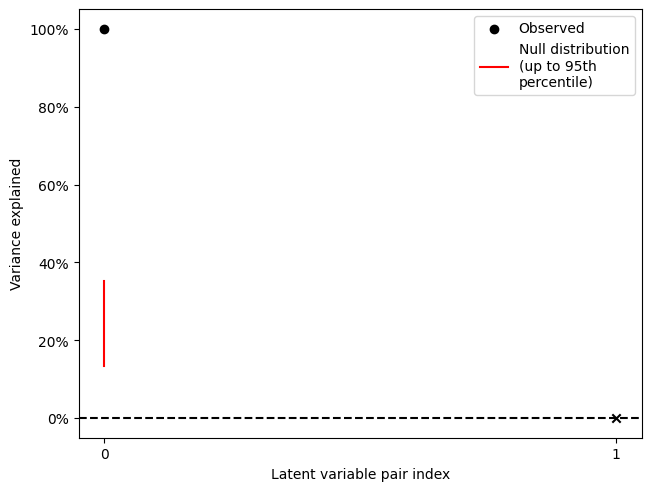

In [12]:
res.permute(100)
print(res.summary())
res.plot_scree()

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: ylabel='Brain score'>,
        <Axes: xlabel='Time (s)', ylabel='Salience'>], dtype=object))

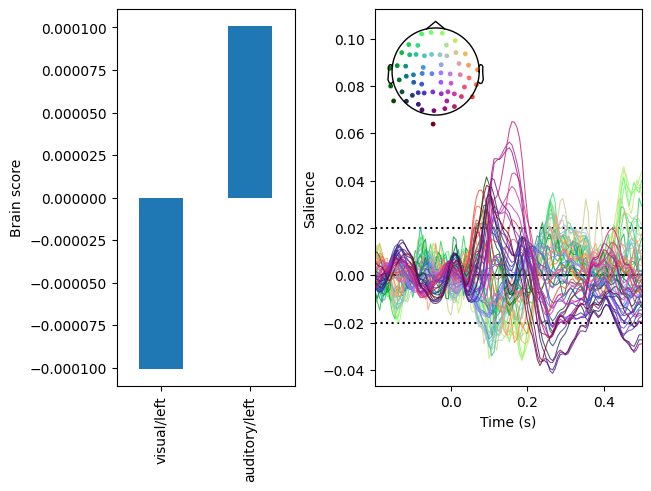

In [13]:
res.plot_lv(0)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Time (s)', ylabel='Brain score'>)

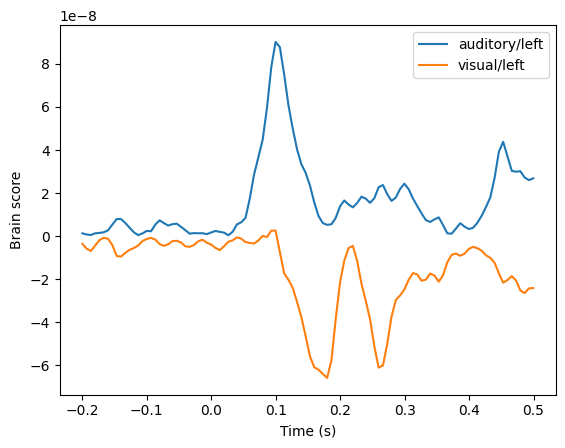

In [14]:
res.plot_marginal_brain_scores(0, 'time')

In [15]:
res.bootstrap(100)
res.add_adjacency()

Resampling: 100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 43.42it/s]

Defaulting to all channels adjacent for ERP/ERF analysis


Defaulting to unsigned clustering for ERP/ERF analysis
Computing clusters for lv_idx 0...
3 clusters
Computing clusters for lv_idx 1...
0 clusters


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Cluster index', ylabel='Cluster size (% of strong saliences)'>)

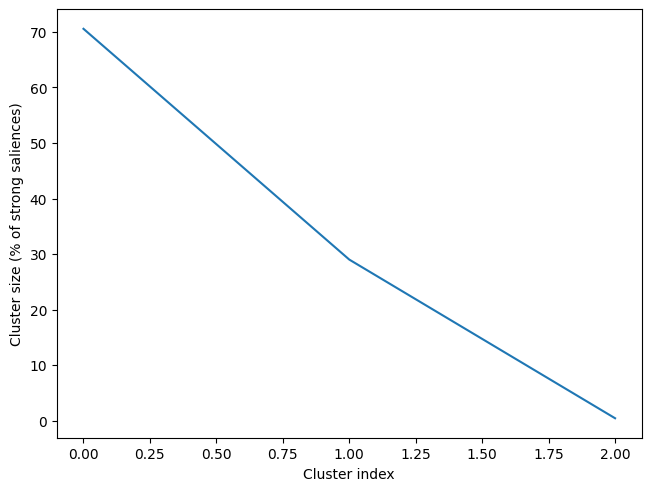

In [20]:
res.cluster(threshold=5, which='z-scores')
res.plot_cluster_sizes(0, n_clust=5)

IndexError: list index out of range

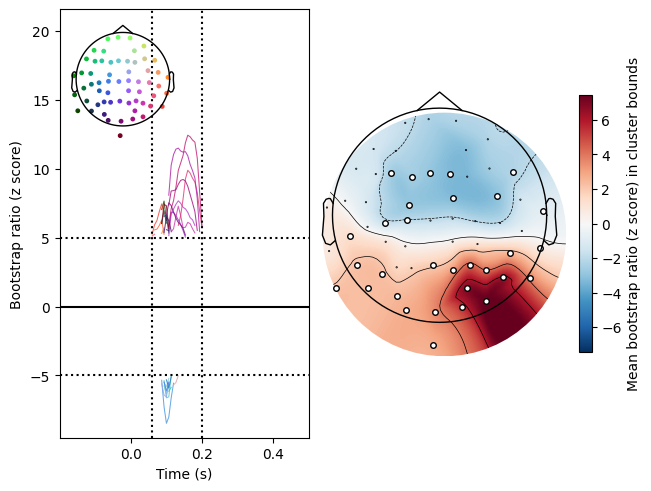

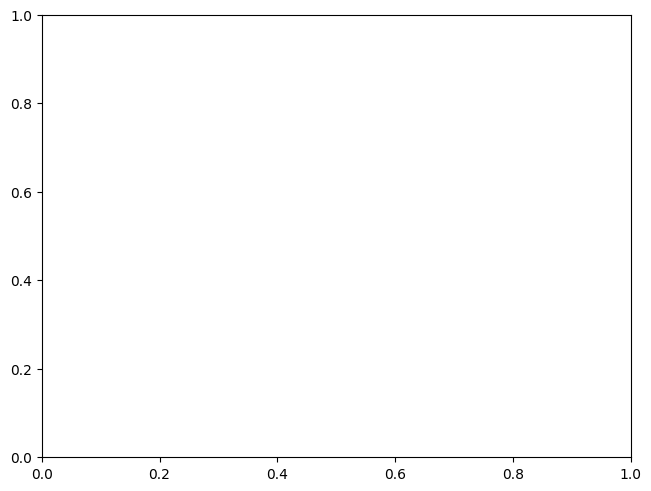

In [23]:
res.plot_clusters(lv_idx=0, cluster_idx=0)
# res.plot_clusters(lv_idx=0, cluster_idx=1)